# Formula 1 Constructors, 1981–2020: Points Leaders, Ferrari's Best Season, and the Rise of Reliability

DATASCI 530 — Assignment 2
Author: *Rola*
Data: Formula 1 World Championship data 

## Summary of findings

| Question | Answer |
|---|---|
| (a) Top constructors, 1981–2020 | Ferrari (7,374 points), Mercedes (5,685) and McLaren (5,229.5). The average across all 67 constructors was 532.2 points, so these three scored 13.9×, 10.7× and 9.8× the average. |
| (b) Top constructors, 2001–2020 | Ferrari (5,862), Mercedes (5,685) and Red Bull (5,043.5). The average across all 35 constructors was 786.0 points, so these three scored 7.5×, 7.2× and 6.4× the average. |
| (c) How the rankings changed | Ferrari and Mercedes stay 1st and 2nd. Red Bull rises from 4th to 3rd and McLaren falls from 3rd to 4th: 37% of McLaren's 1981–2020 points came before 2001, while Red Bull only entered in 2005. McLaren's 3rd place in 1981–2020 depends on 218 points from 2007 that were officially stripped; without them, Red Bull is 3rd in both periods. |
| (d) Ferrari drivers, 1981–2020 | 25 different drivers raced for Ferrari. |
| (e) Ferrari's best year | 2002. Ferrari won 15 of 17 races and took 50% of all points awarded that season, the highest of any year in the period on both measures. Raw points would suggest 2018 (571 points), but that reflects the more generous post-2010 scoring system, and Ferrari finished only 2nd that year. |
| (f–g) New insight: reliability | Cars became far more reliable. Only 44% of race starts reached the finish in 1981–1990, compared with 82% in 2011–2020. About four-fifths of that gain came from fewer mechanical failures, which fell from 40% of starts (about 10 cars per race) to 10% (about 2 cars per race). Point totals from different eras therefore reflect different conditions, not just different scoring rules. |

## Data and methodology

### Tables used

| File | What one row represents | Why it is needed |
|---|---|---|
| `constructor_results.csv` | Points one constructor scored in one race | Main source of constructor points (questions a–c, e) |
| `constructor_standings.csv` | A constructor's championship standing after one race | Final championship position each season (e) |
| `races.csv` | One race | Links each race (`raceId`) to its season (`year`) |
| `constructors.csv` | One constructor (team) | Constructor names |
| `results.csv` | One driver's entry in one race | Which drivers raced for Ferrari (d), race wins (e), and finishing status (f) |
| `drivers.csv` | One driver | Driver names |
| `status.csv` | One finishing status code | Text description of how each entry ended, e.g. "Finished" or "Engine" (f) |

### Key decisions

1. Time periods include both endpoints. "1981–2020" covers the 1981 through 2020 seasons (40 seasons); "2001–2020" covers 20 seasons.
2. Points come from `constructor_results`. The codebook defines its `points` column as "constructor points for race". As a quality check, I confirm these totals are identical to adding up each constructor's driver points in `results`.
3. A constructor is a `constructorId`. Teams that were sold or renamed (for example Stewart → Jaguar → Red Bull) are counted as separate constructors, as they are in the data.
4. The average across constructors includes every constructor that entered at least one race in the period, including teams that scored no points. Because a few teams score most of the points, I also report the median.
5. Disqualified results are kept in the main analysis. McLaren's 2007 points were removed from the official championship after a disqualification, but they were scored on track and are recorded in the data. Section 5 shows how the rankings change if they are removed.
6. Missing values. The raw files use `\N` to mark missing values. A numeric column that contains `\N` is read as text, so I check the column types: every column used in the calculations is read as a number, and `.describe()` shows no missing values in the points columns (Section 2).

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

## 2. Load the data and check data quality

Before merging, I run three checks:

1. Unique primary keys. Each ID should appear only once in its own table; otherwise a merge would duplicate rows.
2. Column types. Columns used in calculations should be numeric. A numeric column containing the `\N` missing-value code would be read as text.
3. Descriptive statistics for points. The `count` from `.describe()` should equal the number of rows, meaning no points are missing.

In [2]:
constructor_results   = pd.read_csv("data_raw/constructor_results.csv")
constructor_standings = pd.read_csv("data_raw/constructor_standings.csv")
races                 = pd.read_csv("data_raw/races.csv")
constructors          = pd.read_csv("data_raw/constructors.csv")
results               = pd.read_csv("data_raw/results.csv")
drivers               = pd.read_csv("data_raw/drivers.csv")
status                = pd.read_csv("data_raw/status.csv")

In [3]:


key_check = pd.DataFrame({
    "Table":       ["constructor_results", "constructor_standings", "races",
                    "constructors", "results", "drivers", "status"],
    "Primary key": ["constructorResultsId", "constructorStandingsId", "raceId",
                    "constructorId", "resultId", "driverId", "statusId"],
    "Rows":        [len(constructor_results), len(constructor_standings), len(races),
                    len(constructors), len(results), len(drivers), len(status)],
    "Unique IDs":  [len(pd.unique(constructor_results["constructorResultsId"])),
                    len(pd.unique(constructor_standings["constructorStandingsId"])),
                    len(pd.unique(races["raceId"])),
                    len(pd.unique(constructors["constructorId"])),
                    len(pd.unique(results["resultId"])),
                    len(pd.unique(drivers["driverId"])),
                    len(pd.unique(status["statusId"]))]
})

(key_check.style.format({"Rows":       "{:,.0f}",
                         "Unique IDs": "{:,.0f}"})
                .hide(axis = "index")
                .set_caption("Table 1. Rows and unique primary keys in each raw table"))

Table,Primary key,Rows,Unique IDs
constructor_results,constructorResultsId,"12,170","12,170"
constructor_standings,constructorStandingsId,"12,941","12,941"
races,raceId,"1,102","1,102"
constructors,constructorId,211,211
results,resultId,"25,840","25,840"
drivers,driverId,857,857
status,statusId,139,139


In [4]:

print("results:")
print(results[["raceId", "driverId", "constructorId", "positionOrder", "points", "statusId"]].dtypes)
print("")
print("constructor_results:")
print(constructor_results[["raceId", "constructorId", "points"]].dtypes)
print("")
print("constructor_standings:")
print(constructor_standings[["raceId", "constructorId", "position"]].dtypes)
print("")
print("races:")
print(races[["raceId", "year", "round"]].dtypes)

results:
raceId             int64
driverId           int64
constructorId      int64
positionOrder      int64
points           float64
statusId           int64
dtype: object

constructor_results:
raceId             int64
constructorId      int64
points           float64
dtype: object

constructor_standings:
raceId           int64
constructorId    int64
position         int64
dtype: object

races:
raceId    int64
year      int64
round     int64
dtype: object


In [5]:


points_descriptives = pd.DataFrame({
    "constructor_results.csv": constructor_results["points"].describe(),
    "results.csv":             results["points"].describe()
})

(points_descriptives.style.format("{:,.1f}")
                          .set_caption("Table 2. Descriptive statistics for points per race"))

,constructor_results.csv,results.csv
count,"12,170.0","25,840.0"
mean,3.8,1.9
std,7.4,4.2
min,0.0,0.0
25%,0.0,0.0
50%,0.0,0.0
75%,4.0,2.0
max,66.0,50.0


Result: every primary key is unique, all columns used in calculations are numeric (so they contain no `\N` codes), and the `count` of points equals the number of rows in both tables (12,170 and 25,840), so no points are missing. On average a constructor scored 3.8 points per race and a driver 1.9 points per race.

## 3. Build the analysis tables

Two merged datasets are used throughout the report:

- `constructor_points`: one row per constructor per race, with the season (`year`) and the constructor's name.
- `driver_results`: one row per driver per race, with the season, the constructor's name, the driver's name and the finishing status.

`constructors`, `races` and `drivers` all have a column called `name`, so I rename it before merging (the pitfall from Lecture 4a). Every merge uses `how = "left"` so no race result is dropped. Afterwards I check that the number of rows did not change and that every row found a match (a row without a match would have a missing value in the added column).

In [ ]:

constructors = constructors.rename(columns = {"name": "constructor_name"})
drivers["driver_name"] = drivers["forename"] + " " + drivers["surname"]

constructor_points = pd.merge(constructor_results,
                              races[["raceId", "year", "round"]],
                              on  = "raceId",
                              how = "left")

constructor_points = pd.merge(constructor_points,
                              constructors[["constructorId", "constructor_name"]],
                              on  = "constructorId",
                              how = "left")

driver_results = pd.merge(results[["resultId", "raceId", "driverId", "constructorId",
                                   "positionOrder", "points", "statusId"]],
                          races[["raceId", "year"]],
                          on  = "raceId",
                          how = "left")

driver_results = pd.merge(driver_results,
                          constructors[["constructorId", "constructor_name"]],
                          on  = "constructorId",
                          how = "left")

driver_results = pd.merge(driver_results,
                          drivers[["driverId", "driver_name"]],
                          on  = "driverId",
                          how = "left")

driver_results = pd.merge(driver_results,
                          status,
                          on  = "statusId",
                          how = "left")

In [7]:

merge_check = pd.DataFrame({
    "Merged dataset":        ["constructor_points", "constructor_points",
                              "driver_results", "driver_results", "driver_results", "driver_results"],
    "Column added (from)":   ["year (races)", "constructor_name (constructors)",
                              "year (races)", "constructor_name (constructors)",
                              "driver_name (drivers)", "status (status)"],
    "Rows before merging":   [len(constructor_results), len(constructor_results),
                              len(results), len(results), len(results), len(results)],
    "Rows after merging":    [len(constructor_points), len(constructor_points),
                              len(driver_results), len(driver_results), len(driver_results), len(driver_results)],
    "Rows without a match":  [len(constructor_points) - constructor_points["year"].describe()["count"],
                              len(constructor_points) - constructor_points["constructor_name"].describe()["count"],
                              len(driver_results) - driver_results["year"].describe()["count"],
                              len(driver_results) - driver_results["constructor_name"].describe()["count"],
                              len(driver_results) - driver_results["driver_name"].describe()["count"],
                              len(driver_results) - driver_results["status"].describe()["count"]]
})

(merge_check.style.format({"Rows before merging":  "{:,.0f}",
                           "Rows after merging":   "{:,.0f}",
                           "Rows without a match": "{:,.0f}"})
                  .hide(axis = "index")
                  .set_caption("Table 3. Merge check: row counts and unmatched rows"))

Merged dataset,Column added (from),Rows before merging,Rows after merging,Rows without a match
constructor_points,year (races),"12,170","12,170",0
constructor_points,constructor_name (constructors),"12,170","12,170",0
driver_results,year (races),"25,840","25,840",0
driver_results,constructor_name (constructors),"25,840","25,840",0
driver_results,driver_name (drivers),"25,840","25,840",0
driver_results,status (status),"25,840","25,840",0


Result: every merge keeps exactly the original number of rows, and every race, constructor, driver and status ID found a match.

### 3.1 Select the two periods

In [8]:
constructor_points_long  = constructor_points.query("(year >= 1981) & (year <= 2020)")
constructor_points_short = constructor_points.query("(year >= 2001) & (year <= 2020)")

driver_results_long  = driver_results.query("(year >= 1981) & (year <= 2020)")
driver_results_short = driver_results.query("(year >= 2001) & (year <= 2020)")

period_overview = pd.DataFrame({
    "Period":         ["1981–2020", "2001–2020"],
    "Seasons":        [len(pd.unique(constructor_points_long["year"])),
                       len(pd.unique(constructor_points_short["year"]))],
    "Races":          [len(pd.unique(constructor_points_long["raceId"])),
                       len(pd.unique(constructor_points_short["raceId"]))],
    "Constructors":   [len(pd.unique(constructor_points_long["constructorId"])),
                       len(pd.unique(constructor_points_short["constructorId"]))],
    "Drivers":        [len(pd.unique(driver_results_long["driverId"])),
                       len(pd.unique(driver_results_short["driverId"]))],
    "Points awarded": [constructor_points_long["points"].sum(),
                       constructor_points_short["points"].sum()]
})

(period_overview.style.format({"Points awarded": "{:,.1f}"})
                      .hide(axis = "index")
                      .set_caption("Table 4. Size of the two analysis periods"))

Period,Seasons,Races,Constructors,Drivers,Points awarded
1981–2020,40,693,67,264,"35,660.0"
2001–2020,20,372,35,113,"27,510.5"


### 3.2 Quality checks on the points data

1. Do the two sources of points agree? A constructor's points in `constructor_results` should equal the sum of its drivers' points in `results`.
2. Which results are flagged as disqualified? In `constructor_results`, the `status` column is `"D"` for disqualified results.

In [9]:
points_check = pd.merge(constructor_points_long.groupby("constructorId")
                                               .agg(points_constructor_table = ('points', 'sum')),
                        driver_results_long.groupby("constructorId")
                                           .agg(points_driver_table = ('points', 'sum')),
                        on  = "constructorId",
                        how = "left")

points_check["difference"] = points_check["points_constructor_table"] - points_check["points_driver_table"]

print(f"1981–2020: constructors compared = {len(points_check)}")
print(f"Smallest difference = {points_check['difference'].min():.1f} points")
print(f"Largest difference  = {points_check['difference'].max():.1f} points")

1981–2020: constructors compared = 67
Smallest difference = 0.0 points
Largest difference  = 0.0 points


In [10]:
disqualified = constructor_points.query('status == "D"')

disqualified_agg = (disqualified.groupby(["constructor_name", "year"])
                                .agg(races  = ('raceId', len),
                                     points = ('points', 'sum')))

(disqualified_agg.style.format({"points": "{:,.0f}"})
                       .set_caption("Disqualified constructor results in the data"))

,,races,points
constructor_name,year,,
McLaren,2007,17,218


Result: the two tables give identical totals for every constructor (the difference is 0 for all 67 constructors), so the choice of points table does not affect the answers. The only disqualified results in the data are McLaren's 17 races in 2007 (218 points). McLaren was excluded from the 2007 constructors' championship, so Section 5 checks whether removing these points changes any ranking.

## 4. Questions (a) and (b): Which constructors earned the most points?

Method. For each period I:

1. Add up each constructor's points with `.groupby().agg()`.
2. Merge in the constructor names. Constructors that did not race in the period have a missing total after the merge and are removed with `.query("total_points >= 0")`, because a missing value never satisfies the condition.
3. Rank constructors from most to fewest points with `.rank()`.
4. Compare the top three with the average across all constructors that raced in the period, both as points above the average (total minus average) and times the average (total divided by average).

In [11]:
totals_long = (constructor_points_long.groupby("constructorId")
                                      .agg(total_points = ('points', 'sum')))

totals_long = pd.merge(constructors[["constructorId", "constructor_name"]],
                       totals_long,
                       on  = "constructorId",
                       how = "left")

totals_long = totals_long.query("total_points >= 0")
totals_long["rank"] = totals_long["total_points"].rank(method = "dense", ascending = False)
totals_long = totals_long.sort_values("total_points", ascending = False)

average_long        = totals_long["total_points"].mean()
median_long         = totals_long["total_points"].median()
n_constructors_long = len(totals_long)

totals_short = (constructor_points_short.groupby("constructorId")
                                        .agg(total_points = ('points', 'sum')))

totals_short = pd.merge(constructors[["constructorId", "constructor_name"]],
                        totals_short,
                        on  = "constructorId",
                        how = "left")

totals_short = totals_short.query("total_points >= 0")
totals_short["rank"] = totals_short["total_points"].rank(method = "dense", ascending = False)
totals_short = totals_short.sort_values("total_points", ascending = False)

average_short        = totals_short["total_points"].mean()
median_short         = totals_short["total_points"].median()
n_constructors_short = len(totals_short)

In [12]:
top3_long = totals_long.iloc[0:3].copy()
top3_long["above_average"] = top3_long["total_points"] - average_long
top3_long["times_average"] = top3_long["total_points"] / average_long

top3_short = totals_short.iloc[0:3].copy()
top3_short["above_average"] = top3_short["total_points"] - average_short
top3_short["times_average"] = top3_short["total_points"] / average_short

dict_rename_top3 = {"rank":             "Rank",
                    "constructor_name": "Constructor",
                    "total_points":     "Total points",
                    "above_average":    "Points above average",
                    "times_average":    "Times the average"}

dict_format_top3 = {"Rank":                 "{:.0f}",
                    "Total points":         "{:,.1f}",
                    "Points above average": "{:,.1f}",
                    "Times the average":    "{:.1f}x"}

list_top3_columns = ["rank", "constructor_name", "total_points", "above_average", "times_average"]

table_top3_long = (top3_long[list_top3_columns]
                   .rename(columns = dict_rename_top3)
                   .style.format(dict_format_top3)
                   .hide(axis = "index")
                   .set_caption(f"Table 5. Top three constructors by total points, 1981–2020. "
                                f"Average across all {n_constructors_long} constructors: "
                                f"{average_long:,.1f} points (median: {median_long:,.1f})"))

table_top3_short = (top3_short[list_top3_columns]
                    .rename(columns = dict_rename_top3)
                    .style.format(dict_format_top3)
                    .hide(axis = "index")
                    .set_caption(f"Table 6. Top three constructors by total points, 2001–2020. "
                                 f"Average across all {n_constructors_short} constructors: "
                                 f"{average_short:,.1f} points (median: {median_short:,.1f})"))

display(table_top3_long)
display(table_top3_short)

Rank,Constructor,Total points,Points above average,Times the average
1,Ferrari,"7,374.0","6,841.8",13.9x
2,Mercedes,"5,685.0","5,152.8",10.7x
3,McLaren,"5,229.5","4,697.3",9.8x


Rank,Constructor,Total points,Points above average,Times the average
1,Ferrari,"5,862.0","5,076.0",7.5x
2,Mercedes,"5,685.0","4,899.0",7.2x
3,Red Bull,"5,043.5","4,257.5",6.4x


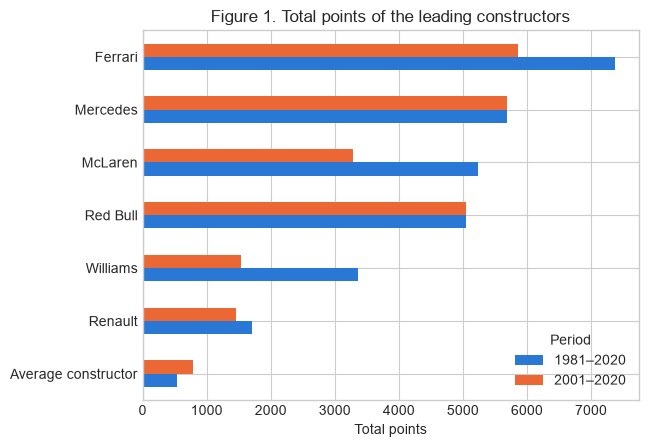

In [13]:

figure1_data = pd.merge(totals_long[["constructor_name", "total_points"]].iloc[0:6],
                        totals_short[["constructor_name", "total_points"]],
                        on  = "constructor_name",
                        how = "left")

average_row = pd.DataFrame({"constructor_name": ["Average constructor"],
                            "total_points_x":   [average_long],
                            "total_points_y":   [average_short]})

figure1_data = pd.concat([figure1_data, average_row])
figure1_data = figure1_data.rename(columns = {"constructor_name": "Constructor",
                                              "total_points_x":   "1981–2020",
                                              "total_points_y":   "2001–2020"})

figure1_data = figure1_data.sort_values("1981–2020", ascending = True)

figure1_data.plot(kind = "barh", x = "Constructor", color = ["#2a78d6", "#eb6834"])
plt.title("Figure 1. Total points of the leading constructors")
plt.xlabel("Total points")
plt.ylabel("")
plt.legend(title = "Period", loc = "lower right")
plt.show()

(a) 1981–2020. Ferrari is the clear leader with 7,374 points, followed by Mercedes (5,685) and McLaren (5,229.5). All three are far above the average constructor, which scored 532.2 points: Ferrari earned 13.9 times the average, Mercedes 10.7 times and McLaren 9.8 times. The average itself is pulled up by these large teams. The median constructor scored only 22 points, and most of the 67 constructors scored very little.

(b) 2001–2020. Ferrari (5,862), Mercedes (5,685) and Red Bull (5,043.5) lead. The top three are much closer together than in the longer period: 818.5 points separate 1st and 3rd, compared with 2,144.5 in 1981–2020. The average is higher (786.0 points) because fewer constructors took part (35 instead of 67) and because the points system became more generous (points to 8th place from 2003, and 25 points for a win from 2010). Even so, each of the top three earned more than six times the average. Figure 1 shows that the same six constructors lead both periods, and that every one of them is far above the average constructor.

## 5. Question (c): How did the rankings change?

Method. I merge each constructor's rank and points in the two periods for the six leading constructors. Because 2001–2020 is part of 1981–2020, any change in ranking must come from results in 1981–2000, so the table also shows the share of each constructor's 1981–2020 points that were scored before 2001.

In [14]:
rank_change = pd.merge(totals_long[["constructor_name", "rank", "total_points"]].iloc[0:6],
                       totals_short[["constructor_name", "rank", "total_points"]],
                       on  = "constructor_name",
                       how = "left")

rank_change["places_gained"]     = rank_change["rank_x"] - rank_change["rank_y"]
rank_change["share_before_2001"] = ((rank_change["total_points_x"] - rank_change["total_points_y"])
                                    / rank_change["total_points_x"] * 100)

rank_change = rank_change.sort_values("rank_y")

(rank_change.rename(columns = {"constructor_name":  "Constructor",
                               "rank_x":            "Rank 1981–2020",
                               "total_points_x":    "Points 1981–2020",
                               "rank_y":            "Rank 2001–2020",
                               "total_points_y":    "Points 2001–2020",
                               "places_gained":     "Places gained",
                               "share_before_2001": "Share of 1981–2020 points scored before 2001"})
            .style.format({"Rank 1981–2020":   "{:.0f}",
                           "Rank 2001–2020":   "{:.0f}",
                           "Points 1981–2020": "{:,.1f}",
                           "Points 2001–2020": "{:,.1f}",
                           "Places gained":    "{:+.0f}",
                           "Share of 1981–2020 points scored before 2001": "{:.1f}%"})
            .hide(axis = "index")
            .set_caption("Table 7. Rankings of the leading constructors in the two periods"))

Constructor,Rank 1981–2020,Points 1981–2020,Rank 2001–2020,Points 2001–2020,Places gained,Share of 1981–2020 points scored before 2001
Ferrari,1,"7,374.0",1,"5,862.0",+0,20.5%
Mercedes,2,"5,685.0",2,"5,685.0",+0,0.0%
Red Bull,4,"5,043.5",3,"5,043.5",+1,0.0%
McLaren,3,"5,229.5",4,"3,284.0",-1,37.2%
Williams,5,"3,355.0",5,"1,535.5",+0,54.2%
Renault,6,"1,710.0",6,"1,465.0",+0,14.3%


### 5.1 Sensitivity check: removing McLaren's disqualified 2007 points

In [15]:
constructor_points_long_excl = constructor_points_long.query('status != "D"')

totals_long_excl = (constructor_points_long_excl.groupby("constructorId")
                                                .agg(total_points = ('points', 'sum')))

totals_long_excl = pd.merge(constructors[["constructorId", "constructor_name"]],
                            totals_long_excl,
                            on  = "constructorId",
                            how = "left")

totals_long_excl = totals_long_excl.query("total_points >= 0")
totals_long_excl["rank"] = totals_long_excl["total_points"].rank(method = "dense", ascending = False)

sensitivity = pd.merge(totals_long[["constructor_name", "rank", "total_points"]].iloc[0:4],
                       totals_long_excl[["constructor_name", "rank", "total_points"]],
                       on  = "constructor_name",
                       how = "left")

sensitivity = sensitivity.sort_values("rank_y")

(sensitivity.rename(columns = {"constructor_name": "Constructor",
                               "rank_x":           "Rank (all points)",
                               "total_points_x":   "Points (all)",
                               "rank_y":           "Rank (without 2007 disqualification)",
                               "total_points_y":   "Points (without 2007 disqualification)"})
            .style.format({"Rank (all points)":                      "{:.0f}",
                           "Points (all)":                           "{:,.1f}",
                           "Rank (without 2007 disqualification)":   "{:.0f}",
                           "Points (without 2007 disqualification)": "{:,.1f}"})
            .hide(axis = "index")
            .set_caption("Table 8. Top four constructors in 1981–2020, with and without "
                         "McLaren's disqualified 2007 points"))

Constructor,Rank (all points),Points (all),Rank (without 2007 disqualification),Points (without 2007 disqualification)
Ferrari,1,"7,374.0",1,"7,374.0"
Mercedes,2,"5,685.0",2,"5,685.0"
Red Bull,4,"5,043.5",3,"5,043.5"
McLaren,3,"5,229.5",4,"5,011.5"


(c) Interpretation.

- Ferrari and Mercedes keep 1st and 2nd place. Mercedes has exactly the same total in both periods because all of its points in these windows were scored from 2010 onward.
- Red Bull and McLaren swap 3rd and 4th. McLaren was one of the strongest teams of the late 1980s and 1990s, and 37.2% of its 1981–2020 points came before 2001. Red Bull entered Formula 1 in 2005, so none of its points are affected by the earlier window. Once the 1981–2000 seasons are removed, McLaren drops behind Red Bull.
- Williams (5th) and Renault (6th) keep their places. More than half of Williams's points (54.2%) came before 2001, but it was far enough ahead of Renault to keep 5th place in both periods.
- Sensitivity check: McLaren's 3rd place in 1981–2020 is fragile. Its lead over Red Bull (186 points) is smaller than the 218 points McLaren lost when it was disqualified from the 2007 championship. Without those points, Red Bull is 3rd in both periods and McLaren 4th, so the 2001–2020 ranking is unchanged either way.
- Part of the pattern reflects the scoring system rather than performance alone: points per race have risen over time, so teams that were successful in recent seasons (Mercedes, Red Bull) collect large totals quickly.

## 6. Question (d): How many different drivers did Ferrari have between 1981 and 2020?

Method. A driver counts as a Ferrari driver if they appear in `results` with Ferrari as their constructor in at least one race from 1981 to 2020. I count unique `driverId` values rather than names, so two drivers who share a name could not be merged by mistake. Because `results` also records entries that failed to qualify or withdrew, I check that counting only drivers who actually started a race gives the same answer.

In [ ]:
ferrari_results = driver_results_long.query('constructor_name == "Ferrari"')

ferrari_starts = ferrari_results.query('(status != "Did not qualify") & (status != "Did not prequalify") '
                                       '& (status != "Withdrew") & (status != "107% Rule")').copy()

n_ferrari_drivers  = len(pd.unique(ferrari_results["driverId"]))
n_ferrari_starters = len(pd.unique(ferrari_starts["driverId"]))

print(f"Different drivers entered by Ferrari, 1981–2020: {n_ferrari_drivers}")
print(f"Different drivers who started at least one race for Ferrari: {n_ferrari_starters}")

Different drivers entered by Ferrari, 1981–2020: 25
Different drivers who started at least one race for Ferrari: 25


In [ ]:

ferrari_drivers = (ferrari_starts.groupby("driverId")
                                 .agg(first_season = ('year', 'min'),
                                      last_season  = ('year', 'max'),
                                      races        = ('raceId', len)))

ferrari_drivers = pd.merge(drivers[["driverId", "driver_name"]],
                           ferrari_drivers,
                           on  = "driverId",
                           how = "left")

ferrari_drivers = ferrari_drivers.query("races >= 1").sort_values("first_season")

(ferrari_drivers[["driver_name", "first_season", "last_season", "races"]]
    .rename(columns = {"driver_name":  "Driver",
                       "first_season": "First season",
                       "last_season":  "Last season",
                       "races":        "Races for Ferrari"})
    .style.format({"First season":      "{:.0f}",
                   "Last season":       "{:.0f}",
                   "Races for Ferrari": "{:.0f}"})
    .hide(axis = "index")
    .set_caption(f"Table 9. The {n_ferrari_starters} drivers who raced for Ferrari, 1981–2020 "
                 "(ordered by first season)"))

Driver,First season,Last season,Races for Ferrari
Didier Pironi,1981,1982,26
Gilles Villeneuve,1981,1982,20
Patrick Tambay,1982,1983,22
Mario Andretti,1982,1982,2
René Arnoux,1983,1985,32
Michele Alboreto,1984,1988,80
Stefan Johansson,1985,1986,31
Gerhard Berger,1987,1995,96
Nigel Mansell,1989,1990,31
Alain Prost,1990,1991,31


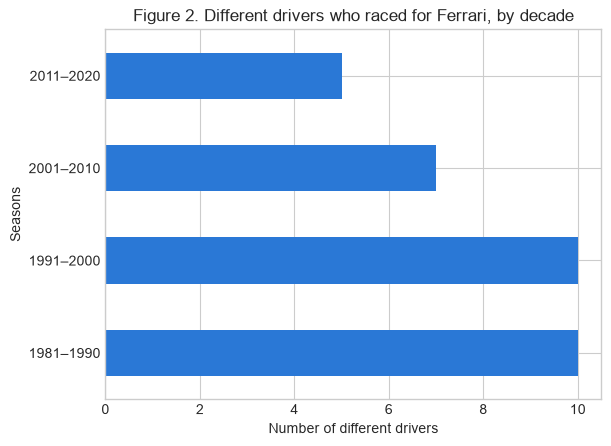

In [ ]:

ferrari_starts["decade"] = pd.cut(ferrari_starts["year"],
                                  bins   = [1980, 1990, 2000, 2010, 2020],
                                  labels = ["1981–1990", "1991–2000", "2001–2010", "2011–2020"],
                                  right  = True)

drivers_per_decade = (ferrari_starts.groupby(["decade", "driverId"]).size()
                                    .groupby("decade").size())

drivers_per_decade.plot(kind = "barh", color = "#2a78d6")
plt.title("Figure 2. Different drivers who raced for Ferrari, by decade")
plt.xlabel("Number of different drivers")
plt.ylabel("Seasons")
plt.show()

(d) Interpretation. 25 different drivers raced for Ferrari between 1981 and 2020, and all 25 started at least one race, so excluding non-starts does not change the answer. Table 9 shows two kinds of drivers:

- Long-term team leaders, such as Michael Schumacher (1996–2006, 181 races), Kimi Räikkönen (152 races over two separate spells) and Felipe Massa (2006–2013, 139 races).
- Short-term substitutes who drove only a handful of races, such as Gianni Morbidelli (1 race in 1991), Mika Salo (6 races in 1999), and Luca Badoer and Giancarlo Fisichella (2009).

Figure 2 shows that driver turnover fell over time: Ferrari used 10 different drivers in both 1981–1990 and 1991–2000, but only 7 in 2001–2010 and 5 in 2011–2020, as the team relied on a few drivers for longer spells. (Drivers whose Ferrari career spans two decades are counted in both.)

## 7. Question (e): What was Ferrari's best year between 1981 and 2020?

Defining "best year". Raw points cannot be compared fairly across these 40 seasons because the scoring system changed (a win was worth 9 points in 1981, 10 points from 1991 and 25 points from 2010) and the number of races per season rose from 15 to 21. I therefore define the best year as the season in which Ferrari earned the largest share of all points awarded, which adjusts for both changes. I also report:

- Wins and win rate (wins ÷ races in the season), from `results`, where `positionOrder == 1` is the race winner.
- Final constructors' championship position, from `constructor_standings` after the last round of each season.

In [19]:
ferrari_points = (constructor_points_long.query('constructor_name == "Ferrari"')
                                         .groupby("year")
                                         .agg(points = ('points', 'sum')))

season_points = (constructor_points_long.groupby("year")
                                        .agg(season_points = ('points', 'sum')))

races_per_season = (races.query("(year >= 1981) & (year <= 2020)")
                         .groupby("year")
                         .agg(races      = ('raceId', len),
                              last_round = ('round', 'max')))

ferrari_wins = (ferrari_results.query("positionOrder == 1")
                               .groupby("year")
                               .agg(wins = ('raceId', len)))

last_races = pd.merge(races[["raceId", "year", "round"]],
                      races_per_season,
                      on  = "year",
                      how = "left")
last_races = last_races.loc[last_races["round"] == last_races["last_round"]]

ferrari_standings = pd.merge(constructor_standings,
                             constructors[["constructorId", "constructor_name"]],
                             on  = "constructorId",
                             how = "left")
ferrari_standings = ferrari_standings.query('constructor_name == "Ferrari"')

ferrari_seasons = pd.merge(last_races[["raceId", "year"]],
                           ferrari_standings[["raceId", "position"]],
                           on  = "raceId",
                           how = "left")

In [ ]:
ferrari_seasons = pd.merge(ferrari_seasons, ferrari_points,   on = "year", how = "left")
ferrari_seasons = pd.merge(ferrari_seasons, season_points,    on = "year", how = "left")
ferrari_seasons = pd.merge(ferrari_seasons, races_per_season, on = "year", how = "left")
ferrari_seasons = pd.merge(ferrari_seasons, ferrari_wins,     on = "year", how = "left")


ferrari_seasons = ferrari_seasons.sort_values("year")

ferrari_seasons["wins"] = ferrari_seasons["wins"].replace([np.nan], [0])

ferrari_seasons["share_of_points"] = ferrari_seasons["points"] / ferrari_seasons["season_points"] * 100
ferrari_seasons["win_rate"]        = ferrari_seasons["wins"] / ferrari_seasons["races"] * 100
ferrari_seasons["rank_by_points"]  = ferrari_seasons["points"].rank(method = "dense", ascending = False)

print(f"Seasons: {len(ferrari_seasons)}")
display(ferrari_seasons[["points", "season_points", "position", "wins"]].describe()
                       .style.format("{:,.1f}")
                       .set_caption("Quality check: descriptive statistics for Ferrari's 40 seasons"))

Seasons: 40


,points,season_points,position,wins
count,40.0,40.0,40.0,40.0
mean,184.3,891.5,2.5,4.0
std,153.9,693.4,1.2,3.9
min,21.0,369.0,1.0,0.0
25%,70.0,402.2,1.8,1.0
50%,129.5,442.0,2.0,3.0
75%,231.2,"1,780.2",3.0,6.0
max,571.0,"2,140.0",6.0,15.0


In [21]:
best_seasons = ferrari_seasons.sort_values("share_of_points", ascending = False).iloc[0:5]

(best_seasons[["year", "share_of_points", "points", "rank_by_points", "wins", "races", "win_rate", "position"]]
    .rename(columns = {"year":            "Season",
                       "share_of_points": "Share of all points",
                       "points":          "Ferrari points",
                       "rank_by_points":  "Rank by raw points (of 40)",
                       "wins":            "Wins",
                       "races":           "Races",
                       "win_rate":        "Win rate",
                       "position":        "Constructors' championship position"})
    .style.format({"Share of all points":                 "{:.1f}%",
                   "Ferrari points":                      "{:,.0f}",
                   "Rank by raw points (of 40)":          "{:.0f}",
                   "Wins":                                "{:.0f}",
                   "Win rate":                            "{:.0f}%",
                   "Constructors' championship position": "{:.0f}"})
    .hide(axis = "index")
    .set_caption("Table 10. Ferrari's five best seasons by share of all points awarded, 1981–2020"))

Season,Share of all points,Ferrari points,Rank by raw points (of 40),Wins,Races,Win rate,Constructors' championship position
2002,50.0%,221,11,15,17,88%,1
2001,40.5%,179,15,9,17,53%,1
2000,38.5%,170,17,10,17,59%,1
2004,37.3%,262,10,15,18,83%,1
1998,32.0%,133,19,6,16,38%,2


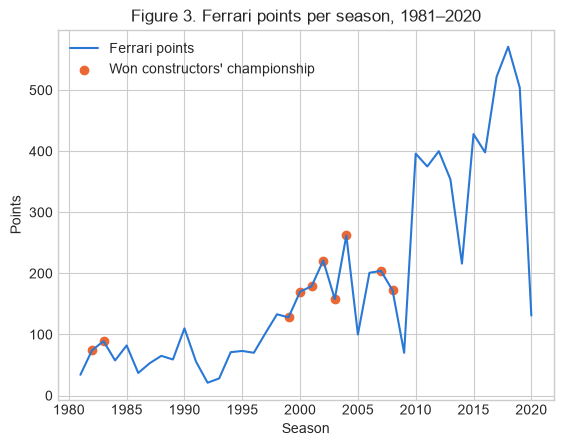

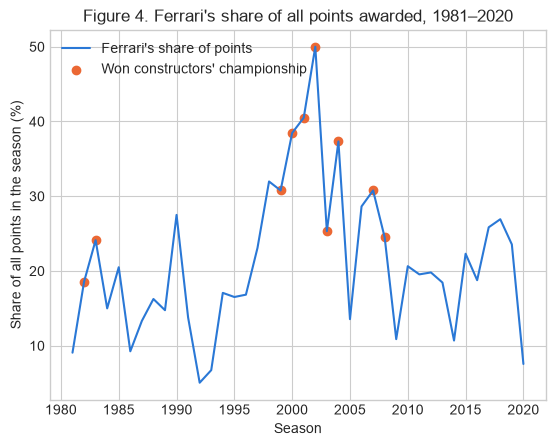

In [22]:
ferrari_titles = ferrari_seasons.query("position == 1")

ferrari_seasons.plot(kind = "line", x = "year", y = "points", color = "#2a78d6")
plt.scatter(x = ferrari_titles["year"], y = ferrari_titles["points"], color = "#eb6834")
plt.title("Figure 3. Ferrari points per season, 1981–2020")
plt.xlabel("Season")
plt.ylabel("Points")
plt.legend(labels = ["Ferrari points", "Won constructors' championship"], loc = "upper left")
plt.show()

ferrari_seasons.plot(kind = "line", x = "year", y = "share_of_points", color = "#2a78d6")
plt.scatter(x = ferrari_titles["year"], y = ferrari_titles["share_of_points"], color = "#eb6834")
plt.title("Figure 4. Ferrari's share of all points awarded, 1981–2020")
plt.xlabel("Season")
plt.ylabel("Share of all points in the season (%)")
plt.legend(labels = ["Ferrari's share of points", "Won constructors' championship"], loc = "upper left")
plt.show()

(e) Interpretation. 2002 was Ferrari's best year. Ferrari took 50.0% of all points awarded that season and won 15 of 17 races (88%), both the highest values in the 40 seasons analyzed, and it won the constructors' championship. The next best seasons by share (2001, 2000 and 2004) belong to the same dominant period, in which Ferrari won six constructors' championships in a row (1999–2004).

Figures 3 and 4 show why the definition matters. By raw points, 2002 ranks only 11th of 40. The top raw-points seasons all come after 2010, when a win became worth 25 points, and the single highest total (571 points in 2018) came in a year Ferrari finished 2nd to Mercedes. Measured as a share of the points available (Figure 4), Ferrari's 2010s seasons were good but never dominant.

## 8. New insight (f): Has Formula 1 become more reliable?

The questions above compare points across very different eras. A natural follow-up is whether the nature of racing itself changed over those 40 years. Using the `status` table, I look at how every race start from 1981 to 2020 ended.

Method. `status.csv` contains more than 130 text status codes. I group them into four outcomes:

| Outcome | Status codes included |
|---|---|
| Finished | "Finished" and "+1 Lap", "+2 Laps", ... (drivers classified at the finish but lapped by the winner) |
| Accident or collision | Accident, Collision, Collision damage, Spun off, Damage, Debris, Fatal accident |
| Other retirement | Disqualified, Excluded, Not classified, unspecified "Retired", and driver health or safety reasons |
| Mechanical or technical failure | Every remaining code: Engine, Gearbox, Electrical, Hydraulics, Suspension, Brakes, and so on |

Entries that never started the race (did not qualify, did not prequalify, withdrew, or failed the 107% rule) are removed first, so each row is a race start. The codes are recoded with `.replace()`, as in Lecture 3a.

In [23]:
race_starts = driver_results_long.query('(status != "Did not qualify") & (status != "Did not prequalify") '
                                        '& (status != "Withdrew") & (status != "107% Rule")').copy()

print(f"Race starts, 1981–2020: {len(race_starts):,}")
print(f"Entries removed because the driver did not start: {len(driver_results_long) - len(race_starts):,}")

list_accident = ["Accident", "Collision", "Collision damage", "Spun off", "Damage", "Debris", "Fatal accident"]
list_other    = ["Disqualified", "Excluded", "Not classified", "Retired", "Driver unwell", "Illness",
                 "Injured", "Injury", "Physical", "Safety", "Safety concerns", "Not restarted", "Underweight"]

list_status_codes = pd.unique(race_starts["status"])
list_finished     = []
list_mechanical   = []

for code in list_status_codes:
    if (code == "Finished") | ("Lap" in code):
        list_finished = list_finished + [code]
    elif not ((code in list_accident) | (code in list_other)):
        list_mechanical = list_mechanical + [code]

race_starts["outcome"] = race_starts["status"].replace(list_finished, "Finished")
race_starts["outcome"] = race_starts["outcome"].replace(list_mechanical, "Mechanical or technical failure")
race_starts["outcome"] = race_starts["outcome"].replace(list_accident, "Accident or collision")
race_starts["outcome"] = race_starts["outcome"].replace(list_other, "Other retirement")

Race starts, 1981–2020: 15,733
Entries removed because the driver did not start: 917


In [24]:
status_groups = pd.DataFrame({
    "Outcome":      ["Finished", "Mechanical or technical failure", "Accident or collision", "Other retirement"],
    "Status codes": [len(list_finished), len(list_mechanical), len(list_accident), len(list_other)],
    "Race starts":  [len(race_starts.query('outcome == "Finished"')),
                     len(race_starts.query('outcome == "Mechanical or technical failure"')),
                     len(race_starts.query('outcome == "Accident or collision"')),
                     len(race_starts.query('outcome == "Other retirement"'))]
})

(status_groups.style.format({"Race starts": "{:,.0f}"})
                    .hide(axis = "index")
                    .set_caption(f"Table 11. Status codes grouped into outcomes "
                                 f"({len(race_starts):,} race starts, 1981–2020)"))

Outcome,Status codes,Race starts
Finished,17,"9,729"
Mechanical or technical failure,72,"3,842"
Accident or collision,7,"1,888"
Other retirement,13,274


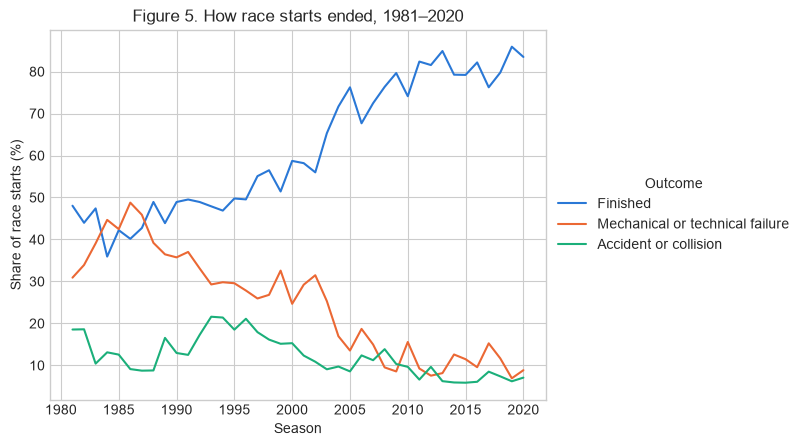

In [25]:
outcomes_by_season = (race_starts.groupby(["year", "outcome"])
                                 .agg(starts = ('raceId', len)))

outcomes_by_season["season_starts"] = outcomes_by_season.groupby("year")["starts"].transform("sum")
outcomes_by_season["share"]         = outcomes_by_season["starts"] / outcomes_by_season["season_starts"] * 100

share_by_season = outcomes_by_season["share"].unstack("outcome")

(share_by_season[["Finished", "Mechanical or technical failure", "Accident or collision"]]
    .plot(kind = "line", color = ["#2a78d6", "#eb6834", "#1baf7a"]))
plt.title("Figure 5. How race starts ended, 1981–2020")
plt.xlabel("Season")
plt.ylabel("Share of race starts (%)")
plt.legend(title = "Outcome", bbox_to_anchor = (1, 0.5), loc = "center left")
plt.show()

In [26]:
race_starts["decade"] = pd.cut(race_starts["year"],
                               bins   = [1980, 1990, 2000, 2010, 2020],
                               labels = ["1981–1990", "1991–2000", "2001–2010", "2011–2020"],
                               right  = True)

outcomes_by_decade = (race_starts.groupby(["decade", "outcome"])
                                 .agg(starts = ('raceId', len)))

outcomes_by_decade["decade_starts"] = outcomes_by_decade.groupby("decade")["starts"].transform("sum")
outcomes_by_decade["share"]         = outcomes_by_decade["starts"] / outcomes_by_decade["decade_starts"] * 100

decade_table = outcomes_by_decade["share"].unstack("outcome")
decade_table = decade_table[["Finished", "Mechanical or technical failure", "Accident or collision", "Other retirement"]]

races_long = races.query("(year >= 1981) & (year <= 2020)").copy()
races_long["decade"] = pd.cut(races_long["year"],
                              bins   = [1980, 1990, 2000, 2010, 2020],
                              labels = ["1981–1990", "1991–2000", "2001–2010", "2011–2020"],
                              right  = True)

races_per_decade      = races_long.groupby("decade").agg(races = ('raceId', len))
mechanical_per_decade = (race_starts.query('outcome == "Mechanical or technical failure"')
                                    .groupby("decade")
                                    .agg(failures = ('raceId', len)))

decade_table["Mechanical failures per race"] = mechanical_per_decade["failures"] / races_per_decade["races"]

(decade_table.style.format({"Finished":                        "{:.1f}%",
                            "Mechanical or technical failure": "{:.1f}%",
                            "Accident or collision":           "{:.1f}%",
                            "Other retirement":                "{:.1f}%",
                            "Mechanical failures per race":    "{:.1f}"})
             .set_caption("Table 12. Outcome of race starts by decade (share of starts)"))

outcome,Finished,Mechanical or technical failure,Accident or collision,Other retirement,Mechanical failures per race
decade,,,,,
1981–1990,44.2%,39.8%,12.9%,3.2%,10.1
1991–2000,51.3%,29.8%,17.7%,1.3%,7.0
2001–2010,69.8%,18.3%,10.8%,1.1%,3.9
2011–2020,81.5%,10.1%,7.0%,1.4%,2.1


## 9. What do we learn? (g)

Formula 1 cars became dramatically more reliable between 1981 and 2020.

- Finishing became the norm. In 1981–1990 only 44.2% of race starts reached the finish. By 2011–2020 the figure was 81.5% (Table 12).
- Fewer mechanical failures explain most of the change. Mechanical or technical failures ended 39.8% of starts in the 1980s, roughly 10 cars per race, but only 10.1% in the 2010s, about 2 cars per race. That drop of 29.7 percentage points accounts for about four-fifths of the 37.3-point rise in the finishing rate. Figure 5 shows the steepest improvement between 2002 and 2005, which coincides with new rules requiring each engine to last a full race weekend (2004) and then two weekends (2005).
- Accidents fell less. Crashes and collisions peaked in the 1990s (17.7% of starts in 1991–2000) and fell to 7.0% in 2011–2020.

Why this matters for the earlier questions. In the 1980s, even the fastest car often broke down, so a team's points depended heavily on whether its car survived the race. In recent seasons almost every car finishes, so points depend more on outright speed. Together with the changes to the points system, this is another reason why raw point totals from different eras should not be compared directly, and why question (e) used each season's share of points instead.

## 10. Limitations

- Points are not directly comparable across eras. Totals for questions (a)–(c) add together seasons with different scoring systems, which favors teams that were successful after 2010. Question (e) addresses this by using each season's share of points.
- Team identity follows the data's constructor IDs. Teams that changed name or owner (for example Tyrrell → BAR → Honda → Brawn → Mercedes) are treated as separate constructors, which affects their totals.
- The outcome groups in Section 8 are my own classification of more than 130 text status codes. A few codes (for example punctures or running out of fuel) could reasonably be placed in a different group, but they are too rare to change the overall trend.
- Disqualifications. Only McLaren's 2007 results are flagged as disqualified in `constructor_results`; the sensitivity check in Section 5.1 shows the one ranking this affects.